# 1. IMPORT AND INSTALL DEPENDENCIES

In [1]:
pip install --upgrade pip

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install tensorflow==2.17.0 opencv-python mediapipe scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.17.0-cp310-cp310-win_amd64.whl.metadata (3.2 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached tensorflow_intel-2.17.0-cp310-cp310-win_amd64.whl.metadata (5.0 kB)
  Using cached ml_dtypes-0.4.1-cp310-cp310-win_amd64.whl.metadata (20 kB)
  Using cached tensorboard-2.17.1-py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.5.3-py3-none-any.whl.metadata (22 kB)
  Using cached jaxlib-0.5.3-cp310-cp310-win_amd64.whl.metadata (1.2 kB)
Using cached tensorflow-2.17.0-cp310-cp310-win_amd64.whl (2.0 kB)
   ---------------------------------------- 0.0/385.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/385.0 MB 8.3 MB/s eta 0:00:47
   ---------------------------------------- 3.1/385.0

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\tatar\\AppData\\Roaming\\Python\\Python310\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



In [3]:
import tensorflow as tf
import sklearn

print("TensorFlow version:", tf.__version__)
print("scikit-learn version:", sklearn.__version__)


TensorFlow version: 2.16.1
scikit-learn version: 1.6.1


In [4]:
import cv2 
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. KEY POINTS USING MP HOLISTIC 

In [5]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawinng utilites

In [6]:
def mediapipe_detection(image, model):
   image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
   image.flags.writeable = False
   results = model.process(image)
   image.flags.writeable = True
   image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR CONVERSION RGB 2 BGR
   return image, results

In [7]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS)
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS)
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS)

In [8]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_CONTOURS, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [9]:
mp_holistic.POSE_CONNECTIONS

frozenset({(0, 1),
           (0, 4),
           (1, 2),
           (2, 3),
           (3, 7),
           (4, 5),
           (5, 6),
           (6, 8),
           (9, 10),
           (11, 12),
           (11, 13),
           (11, 23),
           (12, 14),
           (12, 24),
           (13, 15),
           (14, 16),
           (15, 17),
           (15, 19),
           (15, 21),
           (16, 18),
           (16, 20),
           (16, 22),
           (17, 19),
           (18, 20),
           (23, 24),
           (23, 25),
           (24, 26),
           (25, 27),
           (26, 28),
           (27, 29),
           (27, 31),
           (28, 30),
           (28, 32),
           (29, 31),
           (30, 32)})

In [10]:
cap = cv2.VideoCapture(0)
# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        
        #Read feed
        ret, frame = cap.read()
    
        # Make detection
        image , results = mediapipe_detection(frame, holistic)
        print(results)

        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)
    
        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [11]:
len(results.right_hand_landmarks.landmark)

21

In [12]:
results

mediapipe.python.solution_base.SolutionOutputs

In [13]:
draw_landmarks(frame, results)

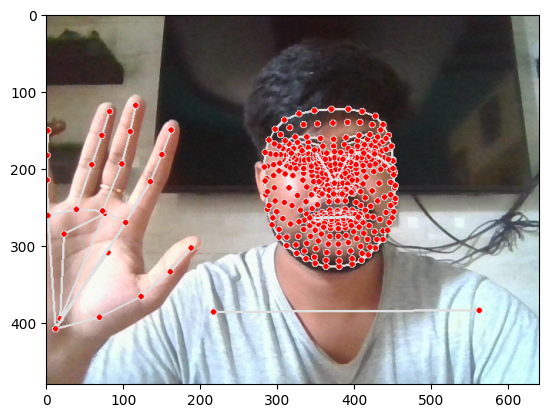

In [14]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. EXTRACT KEY POINT VALUES

In [15]:
results.pose_landmarks

landmark {
  x: 0.585852
  y: 0.456393749
  z: -1.1308322
  visibility: 0.998256743
}
landmark {
  x: 0.619906306
  y: 0.371989459
  z: -1.0714972
  visibility: 0.997627556
}
landmark {
  x: 0.645157337
  y: 0.375811607
  z: -1.07177591
  visibility: 0.99665755
}
landmark {
  x: 0.667033315
  y: 0.379071027
  z: -1.07175219
  visibility: 0.996259
}
landmark {
  x: 0.545233
  y: 0.367836028
  z: -1.03388464
  visibility: 0.998273909
}
landmark {
  x: 0.520090342
  y: 0.370289892
  z: -1.03346574
  visibility: 0.998244047
}
landmark {
  x: 0.497873455
  y: 0.375393569
  z: -1.03437304
  visibility: 0.998791754
}
landmark {
  x: 0.703728199
  y: 0.417277426
  z: -0.600106657
  visibility: 0.996254146
}
landmark {
  x: 0.472764909
  y: 0.424238235
  z: -0.396747172
  visibility: 0.998884201
}
landmark {
  x: 0.632926583
  y: 0.548845
  z: -0.952017
  visibility: 0.996930838
}
landmark {
  x: 0.535149753
  y: 0.550622284
  z: -0.897346
  visibility: 0.998350263
}
landmark {
  x: 0.878377914

In [16]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [17]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [18]:
face

array([ 0.59203589,  0.53200924, -0.03259017, ...,  0.66635746,
        0.37276512,  0.02161739])

In [19]:
lh

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [20]:
rh

array([ 1.92397758e-02,  8.50442052e-01,  6.76557818e-07,  1.09004937e-01,
        8.20039630e-01, -4.05887626e-02,  1.92922443e-01,  7.64021277e-01,
       -5.43150641e-02,  2.52722263e-01,  6.96252823e-01, -6.47854656e-02,
        2.94759214e-01,  6.31753623e-01, -7.30842203e-02,  1.62268251e-01,
        5.63711882e-01, -9.85340960e-03,  2.11658925e-01,  4.52578187e-01,
       -2.66221780e-02,  2.35796183e-01,  3.79599184e-01, -4.63245250e-02,
        2.54368067e-01,  3.12741756e-01, -6.12887256e-02,  1.14553802e-01,
        5.32474935e-01, -6.68224227e-03,  1.53503940e-01,  4.04429555e-01,
       -1.89601146e-02,  1.71036482e-01,  3.17978084e-01, -3.79307568e-02,
        1.82576090e-01,  2.47643411e-01, -5.28453887e-02,  6.22368008e-02,
        5.28955817e-01, -1.01239774e-02,  9.32734534e-02,  4.07372355e-01,
       -2.59628184e-02,  1.12708315e-01,  3.28263074e-01, -4.36255410e-02,
        1.28272325e-01,  2.62720764e-01, -5.64453527e-02,  3.94294411e-03,
        5.44815004e-01, -

In [21]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [22]:
result_test = extract_keypoints(results)[:-10]

In [23]:
result_test

array([ 0.58585203,  0.45639375, -1.1308322 , ..., -0.05644535,
        0.00394294,  0.544815  ])

In [24]:
np.save('0', result_test)

In [25]:
np.load('0.npy')

array([ 0.58585203,  0.45639375, -1.1308322 , ..., -0.05644535,
        0.00394294,  0.544815  ])

# 4. SET UP FOLDERS FOR COLLECTION

In [26]:
#path for the exported data, numpy array
DATA_PATH = os.path.join('NLMS_DATA')

#Actions
actions = np.array(['Namaste', 'Yes', 'No', 'Yawning', 'Shrugging'])

#30 videos worth of data
no_sequences = 30

#30 frames
sequence_length =30


In [27]:
# Namaste

# Yes 

# No


In [27]:
for action in actions :
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH,action,str(sequence)))
        except:
            pass

# 5. COLLECT KEY POINT VALUES FOR TRAINING AND TESTING

In [28]:
cap = cv2.VideoCapture(0)
# Set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:

    # NEW LOOP
    # Loop through actions
    for action in actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            #Loop through video length aka sequence length
            for frame_num in range(sequence_length):
        
                #Read feed
                ret, frame = cap.read()
            
                # Make detection
                image , results = mediapipe_detection(frame, holistic)
                print(results)
        
                # Draw landmarks
                draw_styled_landmarks(image, results)

                # Apply collection logic 
                # NEW Apply wait logic
                if frame_num == 0:
                    cv2.putText(image, 'STARTING COLLECTION', (120,200),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else:
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)
            
                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
            
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [30]:
# Dont run
cap.release()
cv2.destroyAllWindows()

# 6. PREPROCESS DATA AND CREATE LABEL FEATURES

In [31]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [32]:
label_map = {label:num for num, label in enumerate(actions)}

In [33]:
label_map

{'Namaste': 0, 'Yes': 1, 'No': 2, 'Yawning': 3, 'Shrugging': 4}

In [34]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [35]:
np.array(sequences).shape

(150, 30, 1662)

In [36]:
np.array(labels).shape

(150,)

In [37]:
X = np.array(sequences)

In [38]:
y = to_categorical(labels).astype(int)

In [39]:
y

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 1, 0,

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [41]:
X_train.shape

(142, 30, 1662)

In [42]:
X_test.shape

(8, 30, 1662)

In [43]:
y_train.shape

(142, 5)

In [44]:
y_test.shape

(8, 5)

# 7. BUILD AND TRAIN LSTM NEURAL NETWORK

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [46]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [47]:
actions.shape[0]

5

In [48]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input, Bidirectional, BatchNormalization
from keras.optimizers import Adam, AdamW
from keras.regularizers import l2
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers.schedules import ExponentialDecay

# Model definition
model = Sequential()

# Input layer
model.add(Input(shape=(30, 1662)))

# First Bidirectional LSTM Layer with regularization
model.add(Bidirectional(LSTM(256, return_sequences=True, activation='tanh', kernel_regularizer=l2(0.001))))
model.add(Dropout(0.6))  # Increased dropout for better regularization
model.add(BatchNormalization())  # Added batch normalization

# Second Bidirectional LSTM Layer
model.add(Bidirectional(LSTM(256, return_sequences=True, activation='tanh', kernel_regularizer=l2(0.001))))
model.add(Dropout(0.6))  # Increased dropout
model.add(BatchNormalization())  # Added batch normalization

# Third LSTM Layer
model.add(LSTM(128, return_sequences=False, activation='tanh', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.6))  # Increased dropout
model.add(BatchNormalization())  # Added batch normalization

# Fully connected layers with more neurons and dropout
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.5))

# Output layer (Softmax for multi-class classification)
model.add(Dense(5, activation='softmax'))

# Learning Rate Scheduler for better convergence
lr_scheduler = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True
)

# Compile model with AdamW optimizer and a lower learning rate
optimizer = AdamW(learning_rate=lr_scheduler)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Reduce learning rate on plateau for better convergence
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

# Fit the model (using early stopping and learning rate scheduler)
# model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_val, y_val), 
#           callbacks=[early_stopping, reduce_lr])



In [49]:
res = [.7,0.2,0.1]

In [50]:
actions[np.argmax(res)]

'Namaste'

In [51]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [80]:
model.fit(X_train, y_train, epochs=2000, callbacks=[tb_callback])

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 444ms/step - categorical_accuracy: 0.1717 - loss: 6.8053
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - categorical_accuracy: 0.1747 - loss: 6.7203
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - categorical_accuracy: 0.1874 - loss: 6.4666
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - categorical_accuracy: 0.3642 - loss: 6.1523
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - categorical_accuracy: 0.2697 - loss: 6.1798
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - categorical_accuracy: 0.4175 - loss: 5.7660
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 491ms/step - categorical_accuracy: 0.3900 - loss: 5.5487
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 551ms/step - categorical_accuracy: 0.4336 - loss: 5.3977
Epoch 9/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 480ms/step - categorical_accuracy: 0.4627 - loss: 5.2298
Epoch 10/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 518ms/step - categorical_accuracy: 0.4650 - loss: 5.2121
Epoch 11/2000
5/5 ━

KeyboardInterrupt: 

In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 512)        │     3,930,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 512)        │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       328,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,904,389 (22.52 MB)

 Trainable params: 5,902,085 (22.51 MB)

 Non-trainable params: 2,304 (9.00 KB)

# 8. MAKE PREDICTIONS

In [53]:
res = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [54]:
for i in res:
    print(i)

[0.19227414 0.21396588 0.21657155 0.19663243 0.18055592]
[0.1899215  0.20621184 0.23639034 0.18487352 0.18260285]
[0.18976887 0.20517898 0.23839256 0.18546385 0.18119577]
[0.18956211 0.20770119 0.2049567  0.20532139 0.19245867]
[0.20080478 0.2062469  0.23061194 0.18623032 0.17610607]
[0.19143471 0.20628014 0.23870872 0.18438336 0.17919308]
[0.19614795 0.21285194 0.23048863 0.18167906 0.17883241]
[0.197211   0.20917085 0.23673195 0.1828875  0.17399877]


In [55]:
actions[np.argmax(res[4])]

'No'

In [56]:
actions[np.argmax(y_test[4])]

'Yawning'

# 9. SAVE WEIGHTS

In [57]:
model.save('action.keras')

In [58]:
model.load_weights('action.keras')

# 10. EVALUATION USING CONFUSION MATRIX AND ACCURACY

In [59]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [60]:
yhat = model.predict(X_train)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


In [61]:
ytrue = np.argmax(y_train, axis = 1).tolist()
yhat = np.argmax(yhat, axis = 1).tolist()

In [62]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[112,   0],
        [ 30,   0]],

       [[111,   2],
        [ 29,   0]],

       [[  0, 114],
        [  3,  25]],

       [[114,   1],
        [ 27,   0]],

       [[114,   0],
        [ 28,   0]]], dtype=int64)

In [63]:
accuracy_score(ytrue, yhat)

0.176056338028169

# 11. TESTING IN REAL TIME

In [64]:
from scipy import stats

In [65]:
colors = [(245,117,16),(117,245,16),(16,117,245) ,(235,64,52), (117,245,16)]
def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()

    # Ensure `res` is 2D; if it's 1D, convert it to a list of lists
    if isinstance(res[0], (np.float32, float)):
        res = [res]

    for row in res:
        for num, prob in enumerate(row):
            cv2.rectangle(output_frame, (0, 60 + num * 40), (int(prob * 100), 90 + num * 40), colors[num], -1)
            cv2.putText(output_frame, actions[num], (0, 85 + num * 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)

    return output_frame

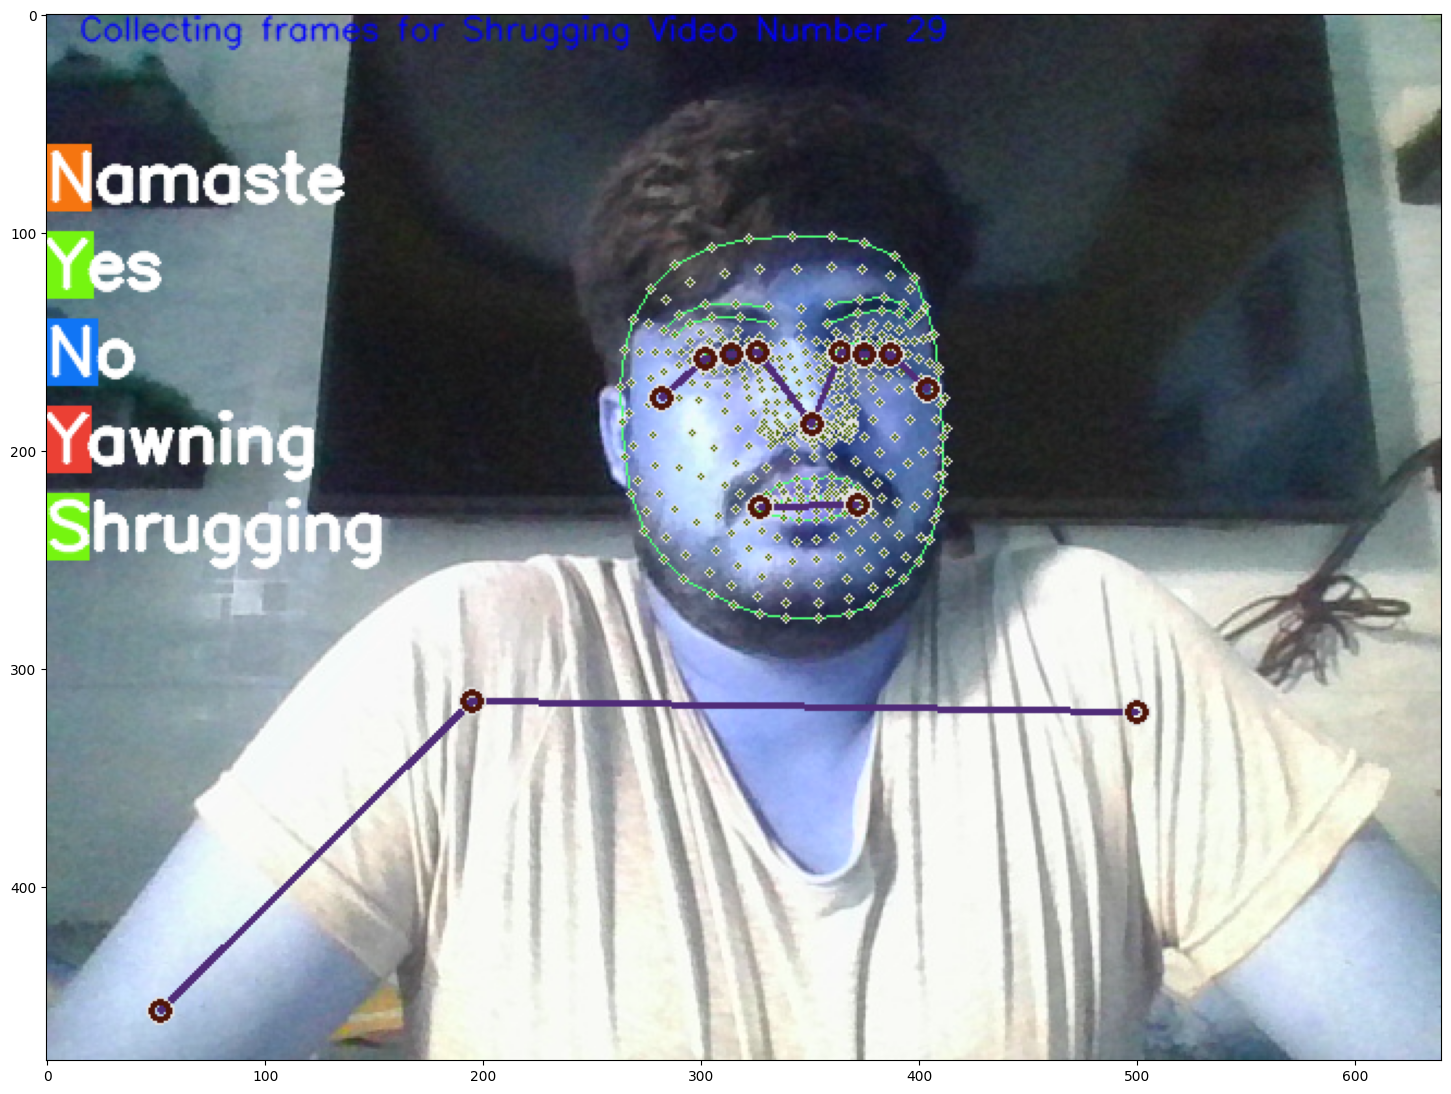

In [66]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [67]:
# 1.New Detection variables
sequence = []
sentence = []
threshold = 0.7

cap = cv2.VideoCapture(0)
# set mediapipe model
with mp_holistic.Holistic(min_detection_confidence=0.5,min_tracking_confidence=0.5) as holistic :
    while cap.isOpened():
        #read feed
        ret, frame = cap.read()

        #make detection
        image,results = mediapipe_detection(frame,holistic)
        print(results)
        
        #draw landmarks
        draw_styled_landmarks(image,results)
        
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        #sequence.insert(0,keypoints)
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold: 
                    
                    if len(sentence) > 0: 
                        if actions[np.argmax(res)] != sentence[-1]:
                            sentence.append(actions[np.argmax(res)])
                    else:
                        sentence.append(actions[np.argmax(res)])

            if len(sentence) > 5: 
                sentence = sentence[-5:]
            #viz probabilities
            image = prob_viz(res,actions,image,colors)
        

            
            cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
            cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
            # show to screen
            cv2.imshow('OpenCV Feed', image)
    
            #break gracefully
            if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [68]:
cap.release()
cv2.destroyAllWindows()